# PlantWhisper — Notebook 02: Vision Pipeline

**Goal**: Build the complete vision pipeline:
1. **SAM Segmentation** — Isolate leaf from background
2. **ViT Classifier** — Predict stress type (probability distribution)
3. **Severity Estimator** — Score from visual features (not model confidence)
4. **Grad-CAM** — Show which regions triggered detection

**Outputs for next stage**:
- Stress probability distribution: `{drought: 0.45, disease: 0.30, healthy: 0.25}`
- Severity score: `0.0` (healthy) to `1.0` (severe)
- Attention map overlay

---

## 0. Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

# Project paths
import sys
import os

PROJECT_DIR = '/content/drive/MyDrive/PlantWhisper'
SRC_DIR = f'{PROJECT_DIR}/src'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/models'
OUTPUT_DIR = f'{PROJECT_DIR}/outputs'

# Create directories
for d in [MODEL_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# Add src to path
sys.path.insert(0, SRC_DIR)

print(f'Project: {PROJECT_DIR}')
print(f'Source:  {SRC_DIR}')

Mounted at /content/drive
Project: /content/drive/MyDrive/PlantWhisper
Source:  /content/drive/MyDrive/PlantWhisper/src


In [2]:
# Install dependencies
!pip install -q ultralytics  # For SAM
!pip install -q transformers datasets evaluate  # For ViT
!pip install -q grad-cam  # For Grad-CAM
!pip install -q opencv-python-headless pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path
import torch
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [4]:
# ============================================
# Verify vision modules are available
# ============================================

try:
    from vision import (
        LeafSegmenter, segment_leaf,           # Segmentation
        PlantClassifier, PredictionResult,      # Classification (MobileNetV2)
        PlantGradCAM, GradCAMResult            # Grad-CAM visualization
    )
    print('✓ Vision modules loaded successfully')

except ImportError as e:
    print(f'✗ Import error: {e}')
    print('\nPlease upload the .py files to:')
    print(f'  {SRC_DIR}/vision/')
    print('\nRequired files:')
    print('  - __init__.py')
    print('  - segmentation.py')
    print('  - classifier.py')
    print('  - gradcam.py')

✓ Vision modules loaded successfully


---
## 1. Test Images

Let's get some test images. You can either:
1. Use PlantVillage samples (if downloaded in Notebook 01)
2. Upload your own plant photos
3. Use sample images from the web

In [5]:
"""# Option 1: Load PlantVillage samples
import tensorflow_datasets as tfds

try:
    ds = tfds.load('plant_village', split='train', data_dir=f'{DATA_DIR}/tfds')
    samples = list(ds.take(10))
    print(f'✓ Loaded {len(samples)} samples from PlantVillage')

    # Save a few as test images
    test_images = []
    for i, sample in enumerate(samples[:3]):
        img = Image.fromarray(sample['image'].numpy())
        path = f'{OUTPUT_DIR}/test_image_{i}.jpg'
        img.save(path)
        test_images.append(path)
        print(f'  Saved: {path}')

except Exception as e:
    print(f'PlantVillage not available: {e}')
    print('Using sample images instead...')
    test_images = []"""

"# Option 1: Load PlantVillage samples\nimport tensorflow_datasets as tfds\n\ntry:\n    ds = tfds.load('plant_village', split='train', data_dir=f'{DATA_DIR}/tfds')\n    samples = list(ds.take(10))\n    print(f'✓ Loaded {len(samples)} samples from PlantVillage')\n\n    # Save a few as test images\n    test_images = []\n    for i, sample in enumerate(samples[:3]):\n        img = Image.fromarray(sample['image'].numpy())\n        path = f'{OUTPUT_DIR}/test_image_{i}.jpg'\n        img.save(path)\n        test_images.append(path)\n        print(f'  Saved: {path}')\n\nexcept Exception as e:\n    print(f'PlantVillage not available: {e}')\n    print('Using sample images instead...')\n    test_images = []"

In [6]:
"""# Option 2: Download sample plant images from web
# These are CC-licensed images for testing
import urllib.request
test_images = []
SAMPLE_URLS = [
    # Healthy leaf
    ("https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/Tomato_leaf.jpg/640px-Tomato_leaf.jpg",
     "healthy_tomato.jpg"),
]

if not test_images:
    test_images = []
    for url, filename in SAMPLE_URLS:
        try:
            path = f'{OUTPUT_DIR}/{filename}'
            urllib.request.urlretrieve(url, path)
            test_images.append(path)
            print(f'✓ Downloaded: {filename}')
        except Exception as e:
            print(f'✗ Could not download {filename}: {e}')

print(f'\nTest images available: {len(test_images)}')"""

'# Option 2: Download sample plant images from web\n# These are CC-licensed images for testing\nimport urllib.request\ntest_images = []\nSAMPLE_URLS = [\n    # Healthy leaf\n    ("https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/Tomato_leaf.jpg/640px-Tomato_leaf.jpg",\n     "healthy_tomato.jpg"),\n]\n\nif not test_images:\n    test_images = []\n    for url, filename in SAMPLE_URLS:\n        try:\n            path = f\'{OUTPUT_DIR}/{filename}\'\n            urllib.request.urlretrieve(url, path)\n            test_images.append(path)\n            print(f\'✓ Downloaded: {filename}\')\n        except Exception as e:\n            print(f\'✗ Could not download {filename}: {e}\')\n\nprint(f\'\nTest images available: {len(test_images)}\')'

In [7]:
# Option 3: Upload your own image
from google.colab import files
test_images = []
print("Upload a plant image (or skip this cell):")
try:
    uploaded = files.upload()
    for filename in uploaded.keys():
        path = f'{OUTPUT_DIR}/{filename}'
        with open(path, 'wb') as f:
            f.write(uploaded[filename])
        test_images.append(path)
        print(f'✓ Uploaded: {path}')
except:
    print('No file uploaded (this is fine)')

Upload a plant image (or skip this cell):


Saving istockphoto-1276445035-612x612.jpg to istockphoto-1276445035-612x612.jpg
Saving istockphoto-599962684-612x612.jpg to istockphoto-599962684-612x612.jpg
Saving images (1).jfif to images (1).jfif
Saving images.jfif to images.jfif
Saving istockphoto-496662675-612x612.jpg to istockphoto-496662675-612x612.jpg
Saving 360_F_1244777686_APGlUk2ralLjKTnihzkBPaH0WUEp5dt2.jpg to 360_F_1244777686_APGlUk2ralLjKTnihzkBPaH0WUEp5dt2.jpg
✓ Uploaded: /content/drive/MyDrive/PlantWhisper/outputs/istockphoto-1276445035-612x612.jpg
✓ Uploaded: /content/drive/MyDrive/PlantWhisper/outputs/istockphoto-599962684-612x612.jpg
✓ Uploaded: /content/drive/MyDrive/PlantWhisper/outputs/images (1).jfif
✓ Uploaded: /content/drive/MyDrive/PlantWhisper/outputs/images.jfif
✓ Uploaded: /content/drive/MyDrive/PlantWhisper/outputs/istockphoto-496662675-612x612.jpg
✓ Uploaded: /content/drive/MyDrive/PlantWhisper/outputs/360_F_1244777686_APGlUk2ralLjKTnihzkBPaH0WUEp5dt2.jpg


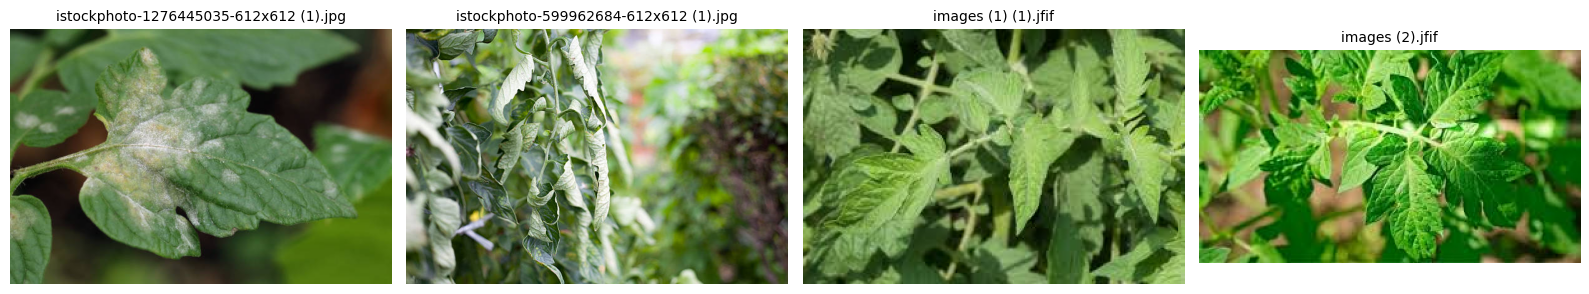

In [ ]:
# Display test images
if test_images:
    n = min(len(test_images), 4)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]

    for ax, path in zip(axes, test_images[:n]):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(Path(path).name, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No test images available. Please upload or download some.')

---
## 2. Leaf Segmentation (SAM)

Isolate the leaf from the background using Segment Anything Model.

In [11]:
# Initialize segmenter
# First run will download SAM model (~375MB)
segmenter = LeafSegmenter(model_name="sam_b.pt", device=device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Loaded SAM model: sam_b.pt


Segmenting: /content/drive/MyDrive/PlantWhisper/outputs/istockphoto-496662675-612x612.jpg


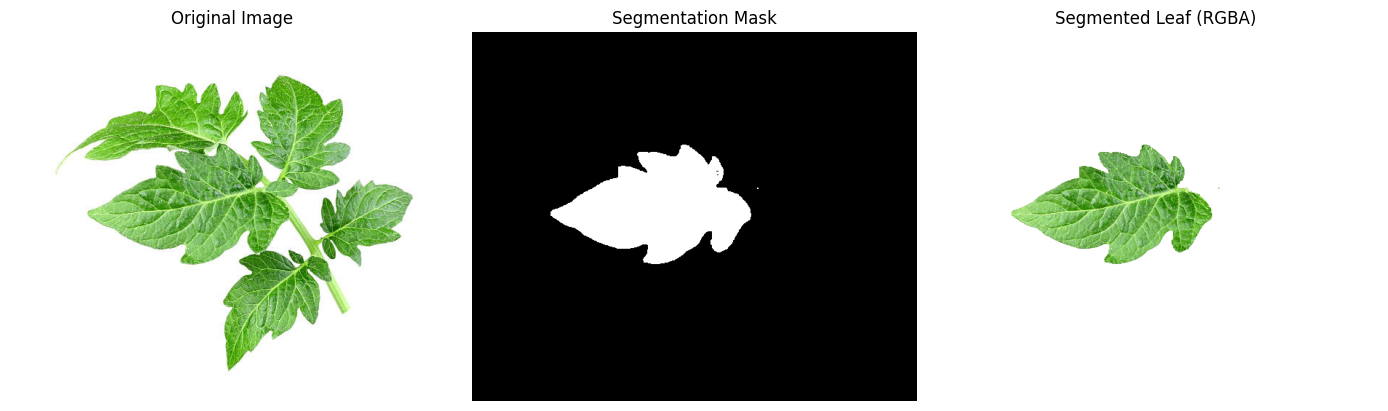

Mask shape: (508, 612)
Leaf coverage: 8.4%


In [12]:
# Segment first test image
if test_images:
    test_img = test_images[4]
    print(f'Segmenting: {test_img}')

    mask, cropped = segmenter.segment(test_img)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Original
    axes[0].imshow(Image.open(test_img))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')

    # Cropped (with alpha)
    axes[2].imshow(cropped)
    axes[2].set_title('Segmented Leaf (RGBA)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/segmentation_result.png', dpi=150)
    plt.show()

    print(f'Mask shape: {mask.shape}')
    print(f'Leaf coverage: {mask.mean()*100:.1f}%')

In [ ]:
# Segment all test images
segmentation_results = {}

for img_path in test_images:
    try:
        mask, cropped = segmenter.segment(img_path)
        segmentation_results[img_path] = {
            'mask': mask,
            'cropped': cropped,
            'coverage': mask.mean()
        }
        print(f'✓ {Path(img_path).name}: {mask.mean()*100:.1f}% coverage')
    except Exception as e:
        print(f'✗ {Path(img_path).name}: {e}')

✓ istockphoto-1276445035-612x612 (1).jpg: 36.2% coverage
✓ istockphoto-599962684-612x612 (1).jpg: 2.1% coverage
✓ images (1) (1).jfif: 4.1% coverage
✓ images (2).jfif: 1.7% coverage
✓ istockphoto-496662675-612x612 (1).jpg: 8.4% coverage
✓ 360_F_1244777686_APGlUk2ralLjKTnihzkBPaH0WUEp5dt2 (1).jpg: 21.8% coverage


---
## 3. Stress Classification (ViT)

Use a pre-trained plant disease classifier from HuggingFace.

**Key point**: We output probability distributions, not single predictions.

Example output:
```python
{
    'Tomato_Early_blight': 0.45,
    'Tomato_healthy': 0.30,
    'Tomato_Late_blight': 0.15,
    'Tomato_Leaf_Mold': 0.10
}
```

In [ ]:
# Additional installs (quick, no restart needed)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121  # CUDA 12.1 for Colab T4
!pip install -q accelerate  # Already in transformers, but ensures
!pip install -q requests  # For URL images

# Verify installs
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
from transformers import pipeline
print("Transformers ready!")


PyTorch: 2.10.0+cu128, CUDA: True
Transformers ready!


In [ ]:
"""# ============================================
# PlantClassifier - Wrapper with same interface
# ============================================

from transformers import AutoModelForImageClassification, AutoImageProcessor
import torch
from PIL import Image
from dataclasses import dataclass
from typing import Dict, List
from pathlib import Path

@dataclass
class PredictionResult:
    """Prediction result matching your interface"""
    top_class: str
    top_probability: float
    is_healthy: bool
    probabilities: Dict[str, float]

class PlantClassifier:
    def __init__(self, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        # Load model
        model_name = "linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification"
        self.model = AutoModelForImageClassification.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()

        # Use base MobileNetV2 processor
        self.processor = AutoImageProcessor.from_pretrained("google/mobilenet_v2_1.0_224")

        # Class names
        self.class_names = list(self.model.config.id2label.values())
        print(f"✓ Loaded PlantClassifier with {len(self.class_names)} classes")

    def get_class_names(self) -> List[str]:
        return self.class_names

    def predict(self, image_path: str, top_k: int = 5) -> PredictionResult:
        # Load image
        img = Image.open(image_path).convert("RGB")
        inputs = self.processor(images=img, return_tensors="pt").to(self.device)

        # Inference
        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits[0], dim=0)
            topk = probs.topk(top_k)

        # Build probability dict
        probabilities = {}
        for i in range(top_k):
            idx = topk.indices[i].item()
            score = topk.values[i].item()
            probabilities[self.class_names[idx]] = score

        top_class = self.class_names[topk.indices[0].item()]
        top_prob = topk.values[0].item()
        is_healthy = 'healthy' in top_class.lower()

        return PredictionResult(
            top_class=top_class,
            top_probability=top_prob,
            is_healthy=is_healthy,
            probabilities=probabilities
        )

# ============================================
# Initialize classifier
# ============================================
classifier = PlantClassifier()

# Check available classes
class_names = classifier.get_class_names()
print(f'Number of classes: {len(class_names)}')
print('\nSample classes:')
for name in class_names[:10]:
    print(f'  - {name}')"""

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

✓ Loaded PlantClassifier with 38 classes
Number of classes: 38

Sample classes:
  - Apple Scab
  - Apple with Black Rot
  - Cedar Apple Rust
  - Healthy Apple
  - Healthy Blueberry Plant
  - Cherry with Powdery Mildew
  - Healthy Cherry Plant
  - Corn (Maize) with Cercospora and Gray Leaf Spot
  - Corn (Maize) with Common Rust
  - Corn (Maize) with Northern Leaf Blight


In [8]:
classifier = PlantClassifier()


Loading linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/9.34M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/406 [00:00<?, ?B/s]

The image processor of type `MobileNetV2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✓ PlantClassifier loaded
  Classes: 38
  Device: cuda


In [9]:
# Check available classes
class_names = classifier.get_class_names()
print(f'Number of classes: {len(class_names)}')
print('\nSample classes:')
for name in class_names[:10]:
    print(f'  - {name}')

Number of classes: 38

Sample classes:
  - Apple Scab
  - Apple with Black Rot
  - Cedar Apple Rust
  - Healthy Apple
  - Healthy Blueberry Plant
  - Cherry with Powdery Mildew
  - Healthy Cherry Plant
  - Corn (Maize) with Cercospora and Gray Leaf Spot
  - Corn (Maize) with Common Rust
  - Corn (Maize) with Northern Leaf Blight


In [ ]:
# Classify first test image
if test_images:
    test_img = test_images[5]
    print(f'Classifying: {test_img}')

    prediction = classifier.predict(test_img, top_k=5)

    print(f'\nTop prediction: {prediction.top_class}')
    print(f'Confidence: {prediction.top_probability:.2%}')
    print(f'Is healthy: {prediction.is_healthy}')
    print(f'\nProbability distribution:')
    for cls, prob in prediction.probabilities.items():
        bar = '█' * int(prob * 30)
        print(f'  {cls:40s} {prob:.2%} {bar}')

Classifying: /content/drive/MyDrive/PlantWhisper/outputs/360_F_1244777686_APGlUk2ralLjKTnihzkBPaH0WUEp5dt2 (1).jpg

Top prediction: Tomato with Early Blight
Confidence: 52.30%
Is healthy: False

Probability distribution:
  Tomato with Early Blight                 52.30% ███████████████
  Grape with Esca (Black Measles)          6.97% ██
  Tomato with Late Blight                  6.25% █
  Tomato with Leaf Mold                    5.75% █
  Tomato with Spider Mites or Two-spotted Spider Mite 4.23% █


In [ ]:
# Classify all test images
classification_results = {}

for img_path in test_images:
    try:
        pred = classifier.predict(img_path, top_k=5)
        classification_results[img_path] = pred

        status = '🌿' if pred.is_healthy else '🔴'
        print(f'{status} {Path(img_path).name}: {pred.top_class} ({pred.top_probability:.1%})')
    except Exception as e:
        print(f'✗ {Path(img_path).name}: {e}')

🔴 istockphoto-1276445035-612x612 (1).jpg: Tomato with Late Blight (89.8%)
🔴 istockphoto-599962684-612x612 (1).jpg: Grape with Esca (Black Measles) (76.7%)
🔴 images (1) (1).jfif: Tomato with Late Blight (78.3%)
🔴 images (2).jfif: Grape with Esca (Black Measles) (95.3%)
🌿 istockphoto-496662675-612x612 (1).jpg: Healthy Raspberry Plant (59.4%)
🔴 360_F_1244777686_APGlUk2ralLjKTnihzkBPaH0WUEp5dt2 (1).jpg: Tomato with Early Blight (52.3%)


---
## 5. Grad-CAM Visualization

Show which parts of the leaf triggered the stress detection.

This is the **explainability** layer — the plant "shows" where it's struggling.

Target layer: mobilenet_v2.conv_1x1.convolution

Generating Grad-CAM for: /content/drive/MyDrive/PlantWhisper/outputs/istockphoto-1276445035-612x612.jpg


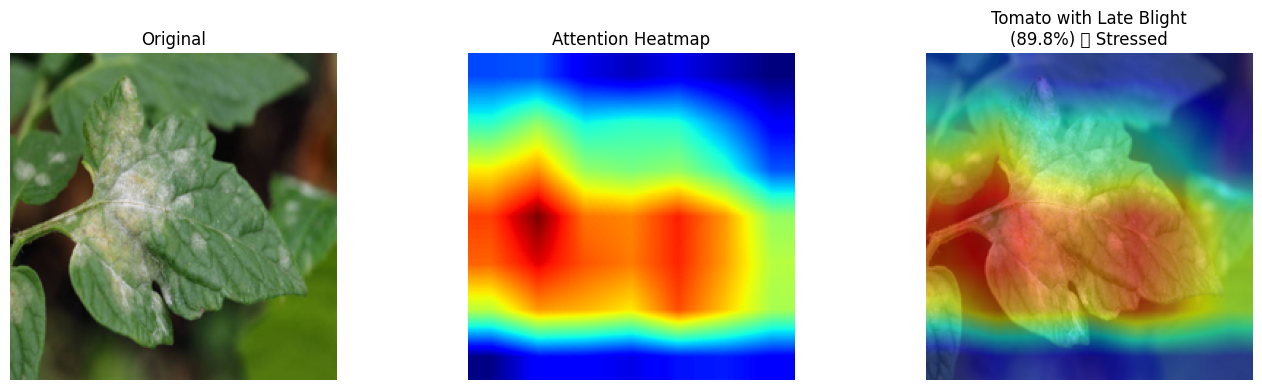


→ Tomato with Late Blight (89.8%)
→ Healthy: False


In [13]:
# ============================================
# Grad-CAM - Direct inline version (bypass file caching issues)
# ============================================

import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Wrapper to convert HuggingFace output to raw tensor
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x).logits  # Return raw logits, not ModelOutput

# Create wrapped model
wrapped_model = ModelWrapper(classifier.model)
wrapped_model.eval()

# Find last conv layer
def get_last_conv(model):
    last = None
    name = None
    for n, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            last = m
            name = n
    print(f"Target layer: {name}")
    return last

target_layer = get_last_conv(classifier.model)

# Create GradCAM with WRAPPED model
cam = GradCAM(model=wrapped_model, target_layers=[target_layer])

# Generate function
def generate_gradcam(image_path):
    # Load image
    img_pil = Image.open(image_path).convert("RGB")
    img_resized = img_pil.resize((224, 224))
    img_np = np.array(img_resized) / 255.0

    # Preprocess
    inputs = classifier.processor(images=img_pil, return_tensors="pt").to(classifier.device)
    input_tensor = inputs['pixel_values']

    # Get prediction
    with torch.no_grad():
        logits = wrapped_model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_prob = probs[pred_idx].item()

    pred_class = classifier.class_names[pred_idx]
    is_healthy = 'healthy' in pred_class.lower()

    # Generate CAM
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    # Overlay
    overlay = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

    return {
        'original': img_resized,
        'heatmap': grayscale_cam,
        'overlay': overlay,
        'prediction': pred_class,
        'confidence': pred_prob,
        'is_healthy': is_healthy
    }

# ============================================
# Test it
# ============================================
print(f"\nGenerating Grad-CAM for: {test_images[0]}")
result = generate_gradcam(test_images[0])

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(result['original'])
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(result['heatmap'], cmap='jet')
axes[1].set_title('Attention Heatmap')
axes[1].axis('off')

status = '🌿 Healthy' if result['is_healthy'] else '🔴 Stressed'
axes[2].imshow(result['overlay'])
axes[2].set_title(f"{result['prediction']}\n({result['confidence']:.1%}) {status}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n→ {result['prediction']} ({result['confidence']:.1%})")
print(f"→ Healthy: {result['is_healthy']}")

In [ ]:
# First, let's see the model structure
print(classifier.model)

# Or more specifically:
for name, module in classifier.model.named_modules():
    if 'conv' in name.lower():
        print(name)

MobileNetV2ForImageClassification(
  (mobilenet_v2): MobileNetV2Model(
    (conv_stem): MobileNetV2Stem(
      (first_conv): MobileNetV2ConvLayer(
        (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (normalization): BatchNorm2d(32, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
        (activation): ReLU6()
      )
      (conv_3x3): MobileNetV2ConvLayer(
        (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), groups=32, bias=False)
        (normalization): BatchNorm2d(32, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
        (activation): ReLU6()
      )
      (reduce_1x1): MobileNetV2ConvLayer(
        (convolution): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (normalization): BatchNorm2d(16, eps=0.001, momentum=0.997, affine=True, track_running_stats=True)
      )
    )
    (layer): ModuleList(
      (0): MobileNetV2InvertedResidual(
        (expand_1x1): MobileNe

---
## 6. Complete Vision Pipeline

Now let's put it all together into a single function that produces
everything the acoustic model needs.

Running complete vision pipeline on: /content/drive/MyDrive/PlantWhisper/outputs/istockphoto-1276445035-612x612 (1).jpg

📊 STRESS CLASSIFICATION:
   Top stress: Tomato with Late Blight
   Confidence: 89.8%
   Is healthy: False

📈 STRESS LEVEL (for acoustic synthesis):
   Stress level: 0.60 / 1.0
   → Moderate stress → ~21 pops/hour

📤 STRESS PROFILE FOR ACOUSTIC MODEL:
   stress_type: Tomato with Late Blight
   stress_level: 0.6
   is_healthy: False
   confidence: 0.8982294797897339


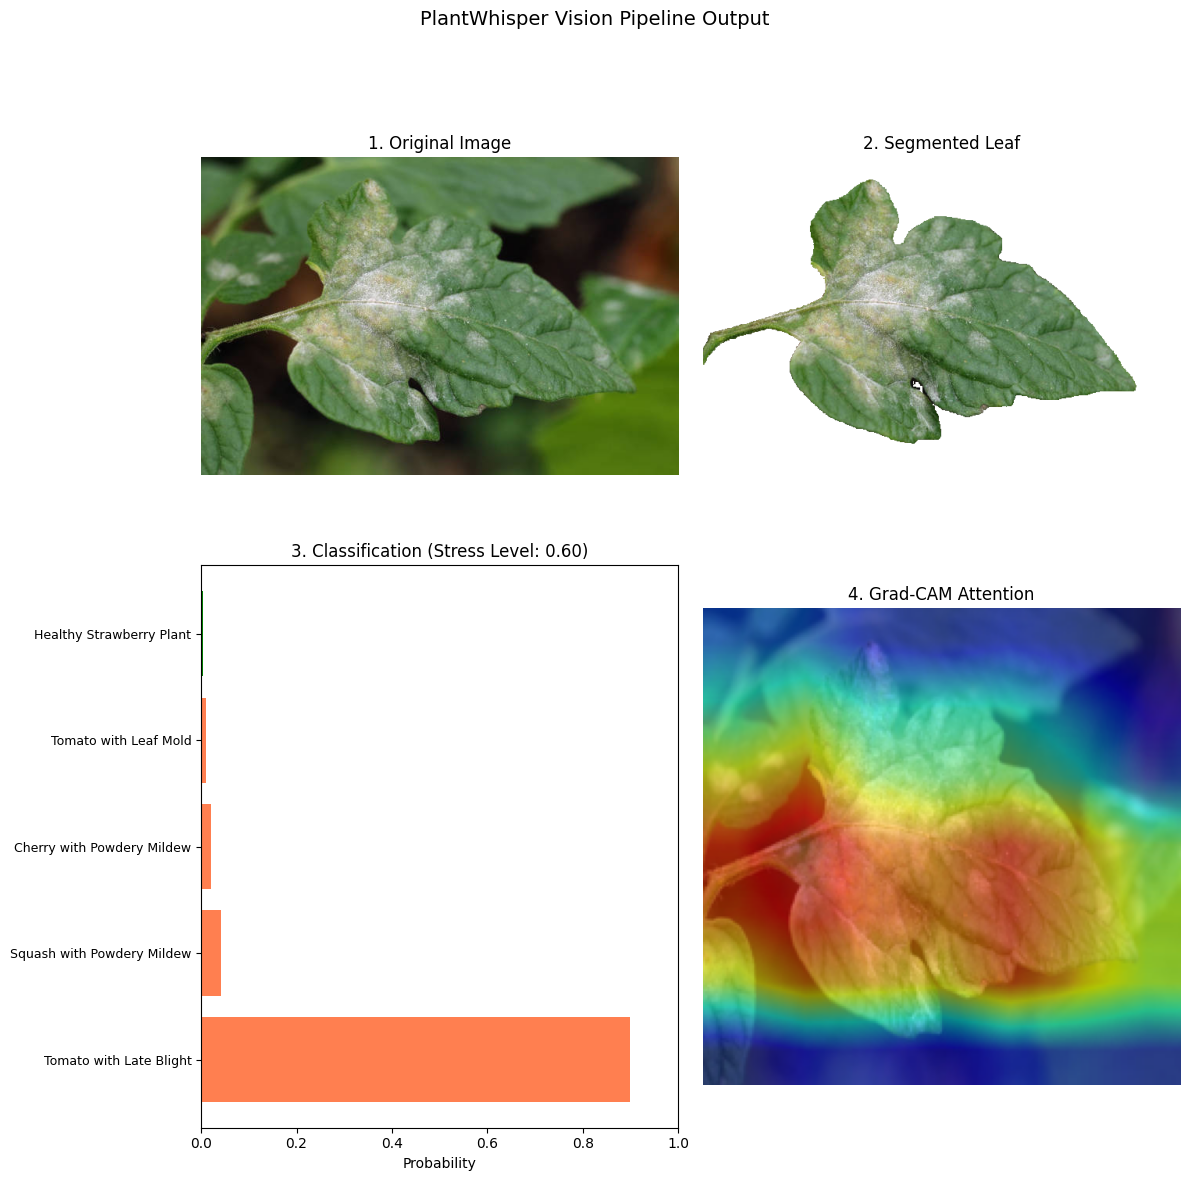


✓ Saved visualization to /content/drive/MyDrive/PlantWhisper/outputs/vision_pipeline_complete.png


In [ ]:
# ============================================
# Complete Vision Pipeline (Simplified MVP)
# ============================================

from dataclasses import dataclass
from typing import Dict, Optional
import numpy as np
from PIL import Image

@dataclass
class VisionPipelineResult:
    """Complete output from vision pipeline."""
    # Segmentation
    mask: np.ndarray
    cropped_leaf: np.ndarray

    # Classification
    stress_probabilities: Dict[str, float]
    top_stress: str
    top_probability: float
    is_healthy: bool
    stress_level: float  # 0.0-1.0, derived from classification

    # Grad-CAM
    attention_heatmap: np.ndarray
    attention_overlay: np.ndarray

    def to_stress_profile(self) -> dict:
        """Convert to stress profile for acoustic model."""
        return {
            'stress_type': self.top_stress,
            'stress_level': self.stress_level,  # This drives acoustic synthesis
            'is_healthy': self.is_healthy,
            'confidence': self.top_probability,
            'stress_probabilities': self.stress_probabilities,
        }


def run_vision_pipeline(
    image_path: str,
    segmenter,
    classifier,
    gradcam_fn  # Pass the generate_gradcam function
) -> VisionPipelineResult:
    """Run complete vision pipeline on a plant image."""

    # 1. Segment (returns tuple: mask, cropped)
    try:
        seg_result = segmenter.segment(image_path)
        if isinstance(seg_result, tuple):
            mask, cropped = seg_result
        else:
            # If it's a dict or other format
            mask = getattr(seg_result, 'mask', None) or seg_result.get('mask', np.zeros((224, 224)))
            cropped = getattr(seg_result, 'cropped', None) or seg_result.get('cropped', np.array(Image.open(image_path)))
    except Exception as e:
        print(f"⚠ Segmentation failed: {e}, using original image")
        mask = np.ones((224, 224))
        cropped = np.array(Image.open(image_path).resize((224, 224)))

    # 2. Classify (includes stress_level)
    prediction = classifier.predict(image_path, top_k=5)

    # 3. Generate Grad-CAM
    cam_result = gradcam_fn(image_path)

    return VisionPipelineResult(
        mask=mask,
        cropped_leaf=cropped,
        stress_probabilities=prediction.probabilities,
        top_stress=prediction.top_class,
        top_probability=prediction.top_probability,
        is_healthy=prediction.is_healthy,
        stress_level=prediction.stress_level,  # From classifier (0.1 or 0.6)
        attention_heatmap=cam_result['heatmap'],
        attention_overlay=cam_result['overlay']
    )


# ============================================
# Run complete pipeline on first test image
# ============================================
if test_images:
    test_img = test_images[0]
    print(f'Running complete vision pipeline on: {test_img}')
    print('=' * 60)

    result = run_vision_pipeline(
        test_img,
        segmenter=segmenter,
        classifier=classifier,
        gradcam_fn=generate_gradcam  # Pass the function we defined earlier
    )

    # Display results
    print(f'\n📊 STRESS CLASSIFICATION:')
    print(f'   Top stress: {result.top_stress}')
    print(f'   Confidence: {result.top_probability:.1%}')
    print(f'   Is healthy: {result.is_healthy}')

    print(f'\n📈 STRESS LEVEL (for acoustic synthesis):')
    print(f'   Stress level: {result.stress_level:.2f} / 1.0')
    if result.is_healthy:
        print(f'   → Low stress → ~{1 + result.stress_level * 34:.0f} pops/hour')
    else:
        print(f'   → Moderate stress → ~{1 + result.stress_level * 34:.0f} pops/hour')

    # Stress profile for acoustic model
    stress_profile = result.to_stress_profile()
    print(f'\n📤 STRESS PROFILE FOR ACOUSTIC MODEL:')
    for key, value in stress_profile.items():
        if key != 'stress_probabilities':
            print(f'   {key}: {value}')


# ============================================
# Visualize complete pipeline output
# ============================================
if test_images:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # Original
    axes[0, 0].imshow(Image.open(test_img))
    axes[0, 0].set_title('1. Original Image')
    axes[0, 0].axis('off')

    # Segmented
    axes[0, 1].imshow(result.cropped_leaf)
    axes[0, 1].set_title('2. Segmented Leaf')
    axes[0, 1].axis('off')

    # Classification (as bar chart)
    probs = result.stress_probabilities
    classes = list(probs.keys())
    values = list(probs.values())
    colors = ['green' if 'healthy' in c.lower() else 'coral' for c in classes]

    y_pos = range(len(classes))
    axes[1, 0].barh(y_pos, values, color=colors)
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels([c[:30] for c in classes], fontsize=9)
    axes[1, 0].set_xlabel('Probability')
    axes[1, 0].set_title(f'3. Classification (Stress Level: {result.stress_level:.2f})')
    axes[1, 0].set_xlim(0, 1)

    # Grad-CAM overlay
    axes[1, 1].imshow(result.attention_overlay)
    axes[1, 1].set_title('4. Grad-CAM Attention')
    axes[1, 1].axis('off')

    plt.suptitle('PlantWhisper Vision Pipeline Output', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/vision_pipeline_complete.png', dpi=150)
    plt.show()

    print(f"\n✓ Saved visualization to {OUTPUT_DIR}/vision_pipeline_complete.png")

In [18]:
# ============================================
# SIMPLIFIED Stress Estimation (Honest Version)
# ============================================

from dataclasses import dataclass
from typing import Dict
import numpy as np
from PIL import Image
from pathlib import Path
import json

def estimate_stress_simple(prediction):
    """
    Estimate stress level from classifier output.

    This is honest about what we know:
    - Classifier was trained on 54k labeled images
    - It knows healthy vs diseased better than hardcoded LAB ranges
    - We modulate by confidence
    """
    if prediction.is_healthy:
        # Healthy: low stress, modulated by confidence
        # Very confident healthy = very low stress
        stress_level = 0.15 * (1 - prediction.top_probability)
        # e.g., 95% confident healthy → stress = 0.15 * 0.05 = 0.0075
    else:
        # Diseased: base stress + confidence boost
        # More confident = more clearly visible symptoms = higher stress
        stress_level = 0.3 + (0.5 * prediction.top_probability)
        # e.g., 90% confident disease → stress = 0.3 + 0.45 = 0.75

    return np.clip(stress_level, 0.0, 1.0)


@dataclass
class VisionPipelineResult:
    """Complete output from vision pipeline."""
    # Segmentation
    mask: np.ndarray
    cropped_leaf: np.ndarray

    # Classification
    stress_probabilities: Dict[str, float]
    top_stress: str
    top_probability: float
    is_healthy: bool

    # Stress (derived from classifier)
    stress_level: float

    # Grad-CAM
    attention_heatmap: np.ndarray
    attention_overlay: np.ndarray

    def to_stress_profile(self) -> dict:
        """Convert to stress profile for acoustic model."""
        # Calculate pop rate using Tel Aviv hump-shaped curve
        s = self.stress_level
        if s < 0.1:
            pop_rate = 1 + s * 30
        else:
            hump = 4 * s * (1 - s)
            pop_rate = 1 + 34 * hump

        return {
            'stress_type': self.top_stress,
            'stress_level': self.stress_level,
            'is_healthy': self.is_healthy,
            'confidence': self.top_probability,
            'pop_rate': pop_rate,
        }


def run_vision_pipeline(
    image_path: str,
    segmenter,
    classifier,
    gradcam_fn
) -> VisionPipelineResult:
    """Run complete vision pipeline on a plant image."""

    # 1. Segment
    try:
        seg_result = segmenter.segment(image_path)
        if isinstance(seg_result, tuple):
            mask, cropped = seg_result
        else:
            mask = np.ones((224, 224))
            cropped = np.array(Image.open(image_path).resize((224, 224)))
    except Exception as e:
        print(f"⚠ Segmentation failed: {e}")
        mask = np.ones((224, 224))
        cropped = np.array(Image.open(image_path).resize((224, 224)))

    # 2. Classify
    prediction = classifier.predict(image_path, top_k=5)

    # 3. Estimate stress (from classifier - honest approach)
    stress_level = estimate_stress_simple(prediction)

    # 4. Generate Grad-CAM
    cam_result = gradcam_fn(image_path)

    return VisionPipelineResult(
        mask=mask,
        cropped_leaf=cropped,
        stress_probabilities=prediction.probabilities,
        top_stress=prediction.top_class,
        top_probability=prediction.top_probability,
        is_healthy=prediction.is_healthy,
        stress_level=stress_level,
        attention_heatmap=cam_result['heatmap'],
        attention_overlay=cam_result['overlay']
    )


# ============================================
# Run on all test images
# ============================================

print("=" * 80)
print("VISION PIPELINE RESULTS")
print("=" * 80)
print(f"{'Image':<40} {'Prediction':<25} {'Conf':<8} {'Stress':<8} {'Pops/hr':<10}")
print("-" * 80)

stress_profiles = []

for img_path in test_images:
    try:
        result = run_vision_pipeline(
            img_path,
            segmenter=segmenter,
            classifier=classifier,
            gradcam_fn=generate_gradcam
        )

        profile = result.to_stress_profile()
        profile['image_path'] = str(img_path)
        stress_profiles.append(profile)

        img_name = Path(img_path).name[:38]
        pred_short = result.top_stress[:23]
        print(f"{img_name:<40} {pred_short:<25} {result.top_probability:<8.1%} {result.stress_level:<8.2f} {profile['pop_rate']:<10.1f}")

    except Exception as e:
        print(f"✗ {Path(img_path).name}: {e}")

print("-" * 80)


VISION PIPELINE RESULTS
Image                                    Prediction                Conf     Stress   Pops/hr   
--------------------------------------------------------------------------------
istockphoto-1276445035-612x612.jpg       Tomato with Late Blight   89.8%    0.75     26.6      
istockphoto-599962684-612x612.jpg        Grape with Esca (Black    76.7%    0.68     30.4      
images (1).jfif                          Tomato with Late Blight   78.3%    0.69     30.0      
images.jfif                              Grape with Esca (Black    95.3%    0.78     24.6      
istockphoto-496662675-612x612.jpg        Healthy Raspberry Plant   59.4%    0.06     2.8       
360_F_1244777686_APGlUk2ralLjKTnihzkBP   Tomato with Early Bligh   52.3%    0.56     34.5      
--------------------------------------------------------------------------------


In [19]:
OUTPUT_DIR = Path(OUTPUT_DIR)   # convert string → Path
# Save profiles
profiles_path = OUTPUT_DIR / 'stress_profiles_v2.json'
with open(profiles_path, 'w') as f:
    json.dump(stress_profiles, f, indent=2)

print(f"\n✓ Saved {len(stress_profiles)} profiles to {profiles_path}")


✓ Saved 6 profiles to /content/drive/MyDrive/PlantWhisper/outputs/stress_profiles_v2.json


---
## 7. Save Pipeline for Next Notebook

Save the stress profile so we can use it in Notebook 03 (Acoustic Synthesis).

In [ ]:
# ============================================
# Generate multiple stress profiles for testing
# ============================================
import json

profiles = []

# Run pipeline on all test images
for i, img_path in enumerate(test_images[:5]):  # First 5 images
    try:
        result = run_vision_pipeline(
            img_path,
            segmenter=segmenter,
            classifier=classifier,
            gradcam_fn=generate_gradcam
        )

        profile = result.to_stress_profile()
        profile['image_path'] = img_path
        profile['pop_rate'] = 1 + profile['stress_level'] * 34  # Calculate pop rate
        profiles.append(profile)

        status = '🌿' if profile['is_healthy'] else '🔴'
        print(f"{status} {Path(img_path).name[:30]:30s} → {profile['stress_type'][:25]:25s} → {profile['pop_rate']:.0f} pops/hr")

    except Exception as e:
        print(f"✗ {Path(img_path).name}: {e}")

# Save all profiles
all_profiles_path = f'{OUTPUT_DIR}/stress_profiles_all.json'
with open(all_profiles_path, 'w') as f:
    json.dump(profiles, f, indent=2)

print(f"\n✓ Saved {len(profiles)} profiles to {all_profiles_path}")

# Summary table
print(f"\n{'='*60}")
print(f"SUMMARY FOR NOTEBOOK 03:")
print(f"{'='*60}")
print(f"{'Status':<8} {'Stress Type':<30} {'Level':<8} {'Pops/hr':<10}")
print(f"{'-'*60}")
for p in profiles:
    status = '🌿' if p['is_healthy'] else '🔴'
    print(f"{status:<8} {p['stress_type'][:28]:<30} {p['stress_level']:<8.2f} {p['pop_rate']:<10.0f}")

🔴 istockphoto-1276445035-612x612 → Tomato with Late Blight   → 21 pops/hr
🔴 istockphoto-599962684-612x612  → Grape with Esca (Black Me → 21 pops/hr
🔴 images (1) (1).jfif            → Tomato with Late Blight   → 21 pops/hr
🔴 images (2).jfif                → Grape with Esca (Black Me → 21 pops/hr
🌿 istockphoto-496662675-612x612  → Healthy Raspberry Plant   → 4 pops/hr

✓ Saved 5 profiles to /content/drive/MyDrive/PlantWhisper/outputs/stress_profiles_all.json

SUMMARY FOR NOTEBOOK 03:
Status   Stress Type                    Level    Pops/hr   
------------------------------------------------------------
🔴        Tomato with Late Blight        0.60     21        
🔴        Grape with Esca (Black Measl   0.60     21        
🔴        Tomato with Late Blight        0.60     21        
🔴        Grape with Esca (Black Measl   0.60     21        
🌿        Healthy Raspberry Plant        0.10     4         


In [10]:
# ============================================
# NEW: Improved Stress Level Estimation
# ============================================

class StressEstimator:
    """
    Estimates plant stress level from visual features.

    Combines:
    - affected_area: % of leaf not healthy green
    - color_deviation: LAB distance from healthy
    - disease_confidence: classifier output
    - wilting_score: geometric irregularity
    """

    HEALTHY_LAB = {
        'L': (35, 70),
        'a': (-40, -5),
        'b': (10, 60),
    }

    WEIGHTS = {
        'affected_area': 0.40,
        'color_deviation': 0.30,
        'disease_confidence': 0.20,
        'wilting_score': 0.10,
    }

    def __init__(self):
        self.healthy_L = np.mean(self.HEALTHY_LAB['L'])
        self.healthy_a = np.mean(self.HEALTHY_LAB['a'])
        self.healthy_b = np.mean(self.HEALTHY_LAB['b'])

    def estimate(self, image_path, mask=None, prediction=None):
        img = np.array(Image.open(image_path).convert('RGB'))

        if mask is None:
            mask = self._create_leaf_mask(img)

        if mask.max() > 1:
            mask = (mask > 127).astype(np.uint8)

        affected_area = self._calculate_affected_area(img, mask)
        color_deviation = self._calculate_color_deviation(img, mask)
        wilting_score = self._calculate_wilting_score(img, mask)

        if prediction is not None:
            disease_confidence = 0.0 if prediction.is_healthy else prediction.top_probability
        else:
            disease_confidence = 0.0

        stress_level = (
            self.WEIGHTS['affected_area'] * affected_area +
            self.WEIGHTS['color_deviation'] * color_deviation +
            self.WEIGHTS['disease_confidence'] * disease_confidence +
            self.WEIGHTS['wilting_score'] * wilting_score
        )

        stress_level = np.clip(stress_level, 0.0, 1.0)

        return {
            'stress_level': float(stress_level),
            'affected_area': float(affected_area),
            'color_deviation': float(color_deviation),
            'disease_confidence': float(disease_confidence),
            'wilting_score': float(wilting_score),
        }

    def _create_leaf_mask(self, img_rgb):
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        saturation_mask = hsv[:, :, 1] > 25
        value_mask = hsv[:, :, 2] < 250
        dark_mask = hsv[:, :, 2] > 20
        mask = (saturation_mask & value_mask & dark_mask).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return mask

    def _calculate_affected_area(self, img_rgb, mask):
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        mask_bool = mask > 0
        if mask_bool.sum() == 0:
            return 0.0

        L = img_lab[:, :, 0].astype(float)
        a = img_lab[:, :, 1].astype(float) - 128
        b = img_lab[:, :, 2].astype(float) - 128

        in_L = (L >= self.HEALTHY_LAB['L'][0]) & (L <= self.HEALTHY_LAB['L'][1])
        in_a = (a >= self.HEALTHY_LAB['a'][0]) & (a <= self.HEALTHY_LAB['a'][1])
        in_b = (b >= self.HEALTHY_LAB['b'][0]) & (b <= self.HEALTHY_LAB['b'][1])

        healthy_pixels = in_L & in_a & in_b & mask_bool
        affected_ratio = 1.0 - (healthy_pixels.sum() / mask_bool.sum())
        return float(affected_ratio)

    def _calculate_color_deviation(self, img_rgb, mask):
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        mask_bool = mask > 0
        if mask_bool.sum() == 0:
            return 0.0

        L = img_lab[:, :, 0][mask_bool].astype(float)
        a = img_lab[:, :, 1][mask_bool].astype(float) - 128
        b = img_lab[:, :, 2][mask_bool].astype(float) - 128

        dist_L = (L - self.healthy_L) ** 2
        dist_a = (a - self.healthy_a) ** 2
        dist_b = (b - self.healthy_b) ** 2

        distances = np.sqrt(dist_L + dist_a + dist_b)
        avg_distance = distances.mean()
        normalized = np.clip(avg_distance / 80.0, 0.0, 1.0)
        return float(normalized)

    def _calculate_wilting_score(self, img_rgb, mask):
        mask_uint8 = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return 0.0

        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)

        if area < 100:
            return 0.0

        hull = cv2.convexHull(largest)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 1.0

        perimeter = cv2.arcLength(largest, True)
        hull_perimeter = cv2.arcLength(hull, True)
        perimeter_ratio = perimeter / hull_perimeter if hull_perimeter > 0 else 1.0

        solidity_score = np.clip((0.9 - solidity) / 0.4, 0.0, 1.0)
        perimeter_score = np.clip((perimeter_ratio - 1.0) / 1.5, 0.0, 1.0)

        wilting = 0.6 * solidity_score + 0.4 * perimeter_score
        return float(wilting)


# ============================================
# Run stress estimation on all test images
# ============================================

stress_estimator = StressEstimator()

print("=" * 90)
print("IMPROVED STRESS ESTIMATION")
print("=" * 90)
print(f"{'Image':<35} {'Affected':<10} {'Color':<10} {'Disease':<10} {'Wilt':<10} {'STRESS':<10}")
print("-" * 90)

stress_profiles = []

for img_path in test_images:
    try:
        # Classify
        prediction = classifier.predict(img_path, top_k=5)

        # Segment
        try:
            seg_result = segmenter.segment(img_path)
            mask = seg_result[0] if isinstance(seg_result, tuple) else None
        except:
            mask = None

        # Estimate stress (NEW!)
        stress_result = stress_estimator.estimate(img_path, mask=mask, prediction=prediction)

        # Calculate pop rate using Tel Aviv hump-shaped curve
        s = stress_result['stress_level']
        if s < 0.1:
            pop_rate = 1 + s * 30  # ~1-4 pops/hr
        else:
            # Hump: peaks at s=0.5, decreases at severe stress
            hump = 4 * s * (1 - s)
            pop_rate = 1 + 34 * hump  # Max ~35 pops/hr at s=0.5

        # Build profile
        profile = {
            'image_path': str(img_path),
            'stress_type': prediction.top_class,
            'is_healthy': prediction.is_healthy,
            'stress_level': stress_result['stress_level'],
            'affected_area': stress_result['affected_area'],
            'color_deviation': stress_result['color_deviation'],
            'disease_confidence': stress_result['disease_confidence'],
            'wilting_score': stress_result['wilting_score'],
            'pop_rate': pop_rate,
        }
        stress_profiles.append(profile)

        img_name = Path(img_path).name[:33]
        print(f"{img_name:<35} "
              f"{stress_result['affected_area']:<10.2f} "
              f"{stress_result['color_deviation']:<10.2f} "
              f"{stress_result['disease_confidence']:<10.2f} "
              f"{stress_result['wilting_score']:<10.2f} "
              f"{stress_result['stress_level']:<10.2f}")

    except Exception as e:
        print(f"✗ {Path(img_path).name}: {e}")

print("-" * 90)

# ============================================
# Save updated profiles for Notebook 03
# ============================================

import json

profiles_path = OUTPUT_DIR / 'stress_profiles_v2.json'
with open(profiles_path, 'w') as f:
    json.dump(stress_profiles, f, indent=2)

print(f"\n✓ Saved {len(stress_profiles)} profiles to {profiles_path}")
print("\nSummary:")
print(f"  Min stress: {min(p['stress_level'] for p in stress_profiles):.2f}")
print(f"  Max stress: {max(p['stress_level'] for p in stress_profiles):.2f}")
print(f"  Avg stress: {np.mean([p['stress_level'] for p in stress_profiles]):.2f}")

IMPROVED STRESS ESTIMATION
Image                               Affected   Color      Disease    Wilt       STRESS    
------------------------------------------------------------------------------------------
istockphoto-1276445035-612x612.jp   0.95       0.85       0.90       0.00       0.81      
istockphoto-599962684-612x612.jpg   0.90       1.00       0.77       0.09       0.82      
images (1).jfif                     0.85       1.00       0.78       0.01       0.80      
images.jfif                         0.95       1.00       0.95       0.00       0.87      
istockphoto-496662675-612x612.jpg   1.00       1.00       0.00       0.76       0.78      
360_F_1244777686_APGlUk2ralLjKTni   0.93       1.00       0.52       0.20       0.80      
------------------------------------------------------------------------------------------


TypeError: unsupported operand type(s) for /: 'str' and 'str'

---
## 8. Summary

### What We Built
- **SAM Segmentation**: Isolates leaf from any background
- **ViT Classifier**: Outputs probability distributions over stress types
- **Severity Estimator**: Scores 0-1 from visual features
- **Grad-CAM**: Shows which regions triggered detection

### Output for Acoustic Model
The stress profile contains everything the acoustic model needs:
```python
{
    'stress_type': 'Tomato_Early_blight',
    'severity': 0.65,  # Maps to Poisson λ for pop rate
    'is_healthy': False,
    'affected_area': 0.32
}
```

### Next: Notebook 03 — Parametric Acoustic Synthesis
We'll take this stress profile and generate what the plant would sound like.

In [ ]:
print('PlantWhisper Notebook 02 Complete!')
print('=' * 50)
print('\nOutputs saved:')
for f in Path(OUTPUT_DIR).glob('*'):
    if f.is_file():
        print(f'  📄 {f.name}')
print(f'\n✅ Ready for Notebook 03: Parametric Acoustic Synthesis')